# Тестирование GenPatchTST: Старая vs Новая реализация

## Проблема CONST SHIFT

Старая реализация GenPatchTST использует `expand()`, что создает одинаковые значения для всех временных шагов последовательности. Это неправильно для генеративной модели, которая должна генерировать разные пертурбации для каждого временного шага.

## Цель теста

1. Показать проблему CONST SHIFT в старой версии
2. Проверить, что новая версия генерирует разные значения
3. Сравнить с GenResidualCNN и GenLSTM для валидации


In [1]:
import sys
sys.path.append('..')

import torch
import numpy as np
import matplotlib.pyplot as plt

from src.models.PatchTST import GenPatchTST, GenPatchTSTOld
from src.models.ResidualCNN import GenResidualCNN
from src.models.LSTM import GenLSTM

# Параметры для тестирования
BATCH_SIZE = 2
SEQ_LEN = 100
C_IN = 1
HIDDEN_DIM = 128

print(f"Тестовые параметры:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Sequence length: {SEQ_LEN}")
print(f"  Input channels: {C_IN}")
print(f"  Hidden dimension: {HIDDEN_DIM}")


CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.


[KeOps] Warning : CUDA was detected, but driver API could not be initialized. Switching to CPU only.
Тестовые параметры:
  Batch size: 2
  Sequence length: 100
  Input channels: 1
  Hidden dimension: 128


In [2]:
# Создаем тестовые данные
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
x = torch.randn(BATCH_SIZE, SEQ_LEN, C_IN).to(device)

print(f"Input shape: {x.shape}")
print(f"Input sample (first batch, first 10 time steps):")
print(x[0, :10, 0].cpu().numpy())


Input shape: torch.Size([2, 100, 1])
Input sample (first batch, first 10 time steps):
[ 0.897544    0.7597324  -0.2403105   0.27257922 -0.60811484  0.30378166
  0.05526009 -0.4041287   0.229192    2.0351849 ]


## Тест 1: Старая реализация GenPatchTSTOld (с CONST SHIFT проблемой)


In [3]:
# Создаем старую модель
model_old = GenPatchTSTOld(
    seq_len=SEQ_LEN,
    hidden_dim=HIDDEN_DIM,
    c_in=C_IN,
    activation_type='tanh'
).to(device)

model_old.eval()
with torch.no_grad():
    output_old = model_old(x)

print(f"Output shape: {output_old.shape}")
print(f"\nOutput для первого батча (первые 10 временных шагов):")
print(output_old[0, :10, 0].cpu().numpy())

# Проверяем, одинаковы ли значения для всех временных шагов
output_first_batch = output_old[0, :, 0].cpu().numpy()
is_constant = np.allclose(output_first_batch, output_first_batch[0])

print(f"\nВсе значения одинаковы? {is_constant}")
if is_constant:
    print("⚠️ ПРОБЛЕМА CONST SHIFT ПОДТВЕРЖДЕНА!")
else:
    std = np.std(output_first_batch)
    print(f"Стандартное отклонение: {std:.6f}")
    if std < 0.001:
        print("⚠️ Почти все значения одинаковы (CONST SHIFT проблема)")


Output shape: torch.Size([2, 100, 1])

Output для первого батча (первые 10 временных шагов):
[-0.10248844 -0.10248844 -0.10248844 -0.10248844 -0.10248844 -0.10248844
 -0.10248844 -0.10248844 -0.10248844 -0.10248844]

Все значения одинаковы? True
⚠️ ПРОБЛЕМА CONST SHIFT ПОДТВЕРЖДЕНА!


## Тест 2: Новая исправленная реализация GenPatchTST


In [4]:
# Создаем новую модель с параметрами из конфига GenPatchTST.yaml
# Ключевая идея: pred_dim=SEQ_LEN, чтобы PatchTST возвращал последовательность нужной длины
model_new = GenPatchTST(
    activation_type='tanh',
    c_in=C_IN,  # Входная размерность (1D)
    seq_len=SEQ_LEN,
    c_out=C_IN,  # Выходная размерность канала (1D)
    pred_dim=SEQ_LEN,  # Размерность предсказания = длина последовательности (КЛЮЧЕВОЙ ПАРАМЕТР!)
    n_layers=2,
    n_heads=8,
    d_model=512,
    d_ff=2048,
    dropout=0.3,
    attn_dropout=0.0,
    patch_len=16,
    stride=8,
    padding_patch=True,
    revin=True,
    affine=False,
    individual=False,
    subtract_last=False,
    decomposition=False,
    kernel_size=25,
    activation='gelu',
    norm='BatchNorm',
    pre_norm=False,
    res_attention=True,
    store_attn=False
).to(device)

model_new.eval()
with torch.no_grad():
    # Проверяем, что возвращает PatchTST напрямую
    x_test = x.transpose(1, 2)
    patch_output = model_new.model(x_test)
    print(f"PatchTST raw output shape: {patch_output.shape}")
    
    output_new = model_new(x)

print(f"Final output shape: {output_new.shape}")
print(f"\nOutput для первого батча (первые 10 временных шагов):")
print(output_new[0, :10, 0].cpu().numpy())

# Проверяем, разные ли значения для разных временных шагов
output_new_first_batch = output_new[0, :, 0].cpu().numpy()
is_constant_new = np.allclose(output_new_first_batch, output_new_first_batch[0])

print(f"\nВсе значения одинаковы? {is_constant_new}")
if not is_constant_new:
    std_new = np.std(output_new_first_batch)
    print(f"✓ Стандартное отклонение: {std_new:.6f}")
    print("✓ Проблема CONST SHIFT исправлена - значения различаются!")
else:
    print("⚠️ Проблема все еще присутствует")
    print(f"  Все значения: {output_new_first_batch[:10]}")


PatchTST raw output shape: torch.Size([2, 1, 100])
Final output shape: torch.Size([2, 100, 1])

Output для первого батча (первые 10 временных шагов):
[ 0.31801444 -0.25196138 -0.17884025 -0.07950184  0.09537748 -0.56284773
 -0.13950723  0.28137654  0.18991464 -0.33825353]

Все значения одинаковы? False
✓ Стандартное отклонение: 0.348342
✓ Проблема CONST SHIFT исправлена - значения различаются!


## Тест 3: Сравнение с GenResidualCNN и GenLSTM (для валидации)


In [5]:
# Тестируем GenResidualCNN
model_rescnn = GenResidualCNN(
    hidden_dim=HIDDEN_DIM,
    x_dim=C_IN,
    activation_type='tanh'
).to(device)

model_rescnn.eval()
with torch.no_grad():
    output_rescnn = model_rescnn(x)

print("GenResidualCNN:")
print(f"  Output shape: {output_rescnn.shape}")
output_rescnn_first = output_rescnn[0, :, 0].cpu().numpy()
std_rescnn = np.std(output_rescnn_first)
print(f"  Стандартное отклонение: {std_rescnn:.6f}")
print(f"  Первые 10 значений: {output_rescnn_first[:10]}")

print("\n" + "="*50)

# Тестируем GenLSTM
model_lstm = GenLSTM(
    hidden_dim=HIDDEN_DIM,
    x_dim=C_IN,
    activation_type='identity'
).to(device)

model_lstm.eval()
with torch.no_grad():
    output_lstm = model_lstm(x)

print("GenLSTM:")
print(f"  Output shape: {output_lstm.shape}")
output_lstm_first = output_lstm[0, :, 0].cpu().numpy()
std_lstm = np.std(output_lstm_first)
print(f"  Стандартное отклонение: {std_lstm:.6f}")
print(f"  Первые 10 значений: {output_lstm_first[:10]}")


GenResidualCNN:
  Output shape: torch.Size([2, 100, 1])
  Стандартное отклонение: 0.005059
  Первые 10 значений: [0.00687976 0.00666543 0.00822888 0.00592628 0.01201379 0.00597306
 0.00561291 0.00991204 0.00586074 0.00860707]

GenLSTM:
  Output shape: torch.Size([2, 100, 1])
  Стандартное отклонение: 0.005547
  Первые 10 значений: [-0.01265669 -0.02149725 -0.02639018 -0.02985565 -0.03088929 -0.03229039
 -0.03321738 -0.03325688 -0.03391742 -0.0382187 ]


## Тест 4: Визуализация сравнения


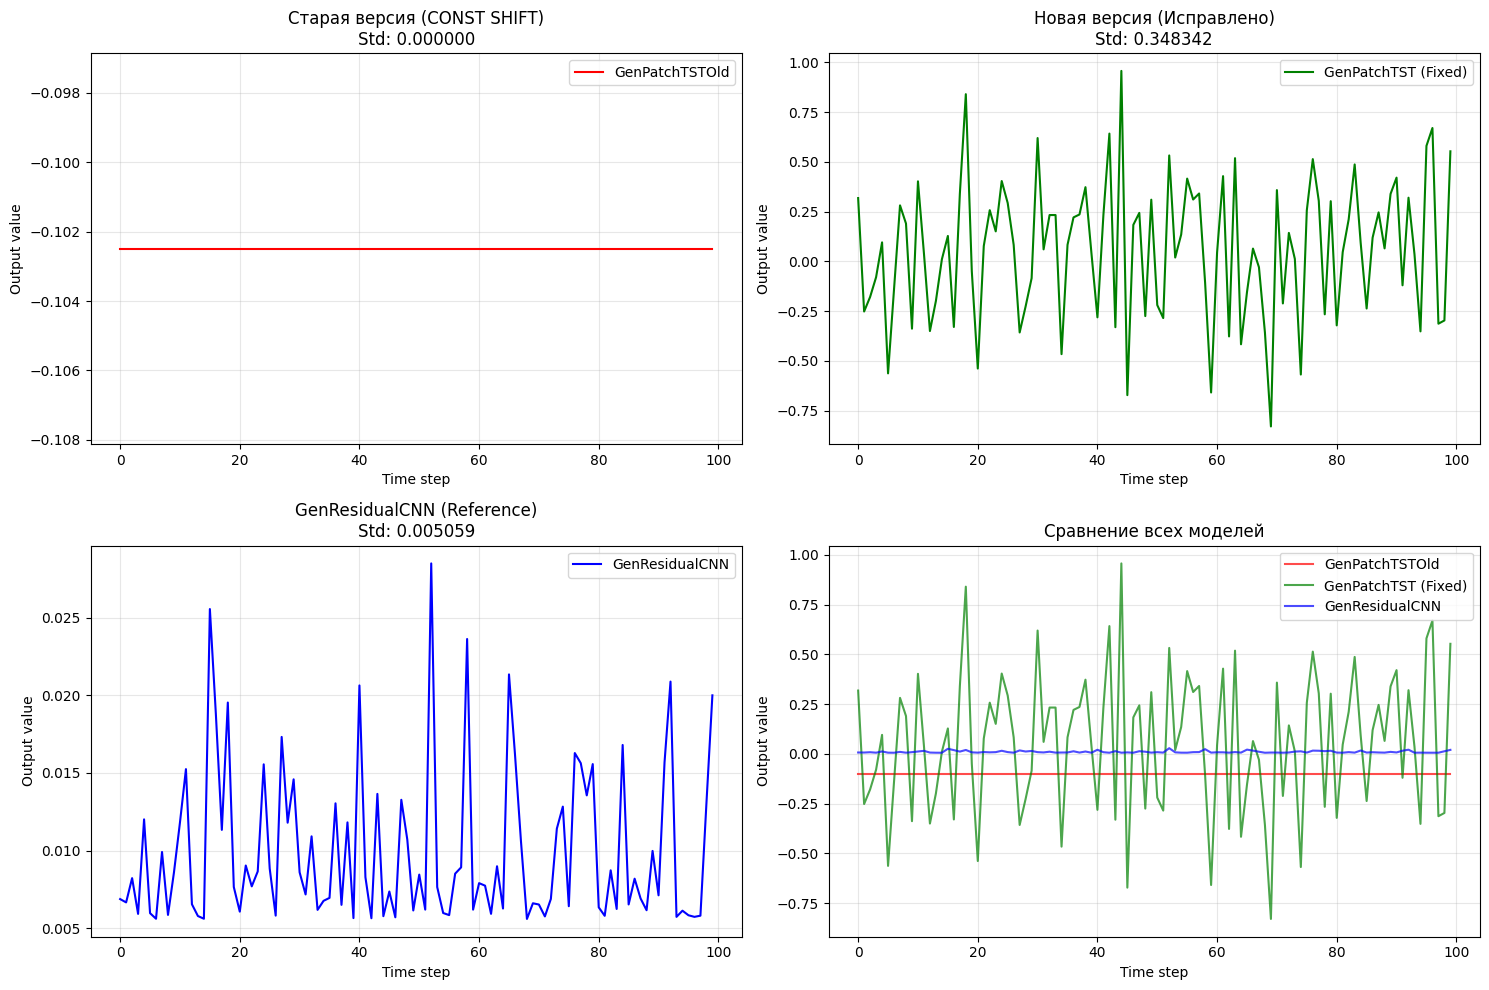


СТАТИСТИКА СТАНДАРТНЫХ ОТКЛОНЕНИЙ:
GenPatchTSTOld:        std = 0.000000
GenPatchTST (Fixed):    std = 0.348342
GenResidualCNN:         std = 0.005059
GenLSTM:                std = 0.005547


In [6]:
# Визуализируем выходы для сравнения
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Старая версия
axes[0, 0].plot(output_old[0, :, 0].cpu().numpy(), label='GenPatchTSTOld', color='red')
axes[0, 0].set_title(f'Старая версия (CONST SHIFT)\nStd: {np.std(output_old[0, :, 0].cpu().numpy()):.6f}')
axes[0, 0].set_xlabel('Time step')
axes[0, 0].set_ylabel('Output value')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Новая версия
axes[0, 1].plot(output_new[0, :, 0].cpu().numpy(), label='GenPatchTST (Fixed)', color='green')
axes[0, 1].set_title(f'Новая версия (Исправлено)\nStd: {np.std(output_new[0, :, 0].cpu().numpy()):.6f}')
axes[0, 1].set_xlabel('Time step')
axes[0, 1].set_ylabel('Output value')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# GenResidualCNN
axes[1, 0].plot(output_rescnn[0, :, 0].cpu().numpy(), label='GenResidualCNN', color='blue')
axes[1, 0].set_title(f'GenResidualCNN (Reference)\nStd: {np.std(output_rescnn[0, :, 0].cpu().numpy()):.6f}')
axes[1, 0].set_xlabel('Time step')
axes[1, 0].set_ylabel('Output value')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Сравнение всех
axes[1, 1].plot(output_old[0, :, 0].cpu().numpy(), label='GenPatchTSTOld', alpha=0.7, color='red')
axes[1, 1].plot(output_new[0, :, 0].cpu().numpy(), label='GenPatchTST (Fixed)', alpha=0.7, color='green')
axes[1, 1].plot(output_rescnn[0, :, 0].cpu().numpy(), label='GenResidualCNN', alpha=0.7, color='blue')
axes[1, 1].set_title('Сравнение всех моделей')
axes[1, 1].set_xlabel('Time step')
axes[1, 1].set_ylabel('Output value')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Статистика
print("\n" + "="*60)
print("СТАТИСТИКА СТАНДАРТНЫХ ОТКЛОНЕНИЙ:")
print("="*60)
print(f"GenPatchTSTOld:        std = {np.std(output_old[0, :, 0].cpu().numpy()):.6f}")
print(f"GenPatchTST (Fixed):    std = {np.std(output_new[0, :, 0].cpu().numpy()):.6f}")
print(f"GenResidualCNN:         std = {np.std(output_rescnn[0, :, 0].cpu().numpy()):.6f}")
print(f"GenLSTM:                std = {np.std(output_lstm[0, :, 0].cpu().numpy()):.6f}")


## Выводы

1. **Старая версия (GenPatchTSTOld)**: Имеет проблему CONST SHIFT - все временные шаги получают одинаковые значения
2. **Новая версия (GenPatchTST)**: Должна генерировать разные значения для каждого временного шага
3. **Сравнение с эталонными моделями**: GenResidualCNN и GenLSTM работают правильно
